In [10]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Our dataset
data = {
    "Bandgap_eV": [2.8, 1.1, 3.2, 3.4, 3.4, 1.2, 2.2, 2.4, 3.6, 3.6],
    "Application": [
        "Photocatalysis", "Solar cells", "Photocatalysis",
        "LEDs", "LEDs", "Solar cells",
        "Batteries", "Solar cells", "Phosphors", "Gas sensors"
    ]
}

df = pd.DataFrame(data)

# X = input (bandgap), y = output (application)
X = df[["Bandgap_eV"]]
y = df["Application"]

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build the model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Test the model
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("=== ML Model Results ===")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Model Accuracy: {accuracy * 100:.1f}%")
print()

# Predict new materials!
print("=== Predicting New Materials ===")
new_materials = pd.DataFrame({"Bandgap_eV": [1.5, 2.9, 3.5, 0.8]})
new_predictions = model.predict(new_materials)

for bandgap, prediction in zip([1.5, 2.9, 3.5, 0.8], new_predictions):
    print(f"Bandgap {bandgap} eV → Predicted use: {prediction}")

=== ML Model Results ===
Training samples: 8
Testing samples: 2
Model Accuracy: 50.0%

=== Predicting New Materials ===
Bandgap 1.5 eV → Predicted use: Solar cells
Bandgap 2.9 eV → Predicted use: Photocatalysis
Bandgap 3.5 eV → Predicted use: LEDs
Bandgap 0.8 eV → Predicted use: Solar cells


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


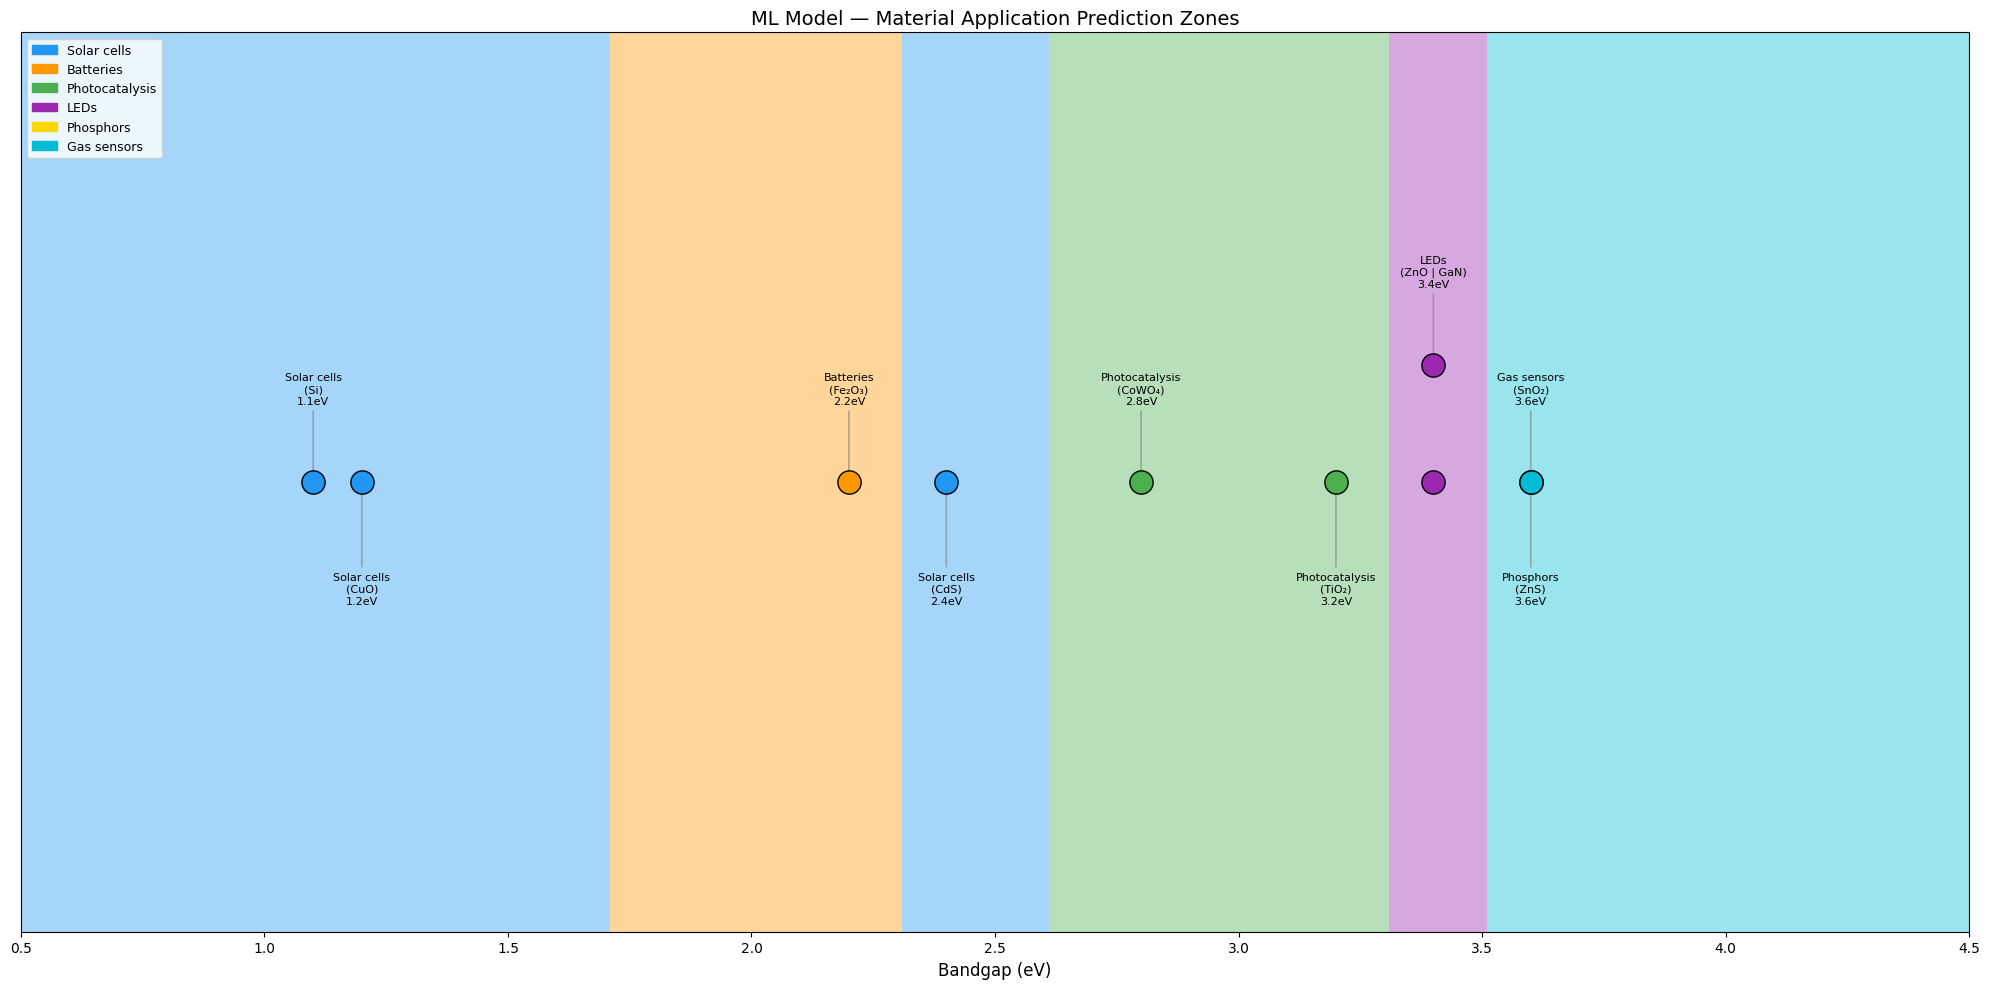

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.tree import DecisionTreeClassifier
from collections import defaultdict

data = {
    "Material": [
        "Cobalt Tungstate", "Silicon", "Titanium Dioxide",
        "Zinc Oxide", "Gallium Nitride", "Copper Oxide",
        "Iron Oxide", "Cadmium Sulfide", "Zinc Sulfide", "Tin Oxide"
    ],
    "Bandgap_eV": [2.8, 1.1, 3.2, 3.4, 3.4, 1.2, 2.2, 2.4, 3.6, 3.6],
    "Application": [
        "Photocatalysis", "Solar cells", "Photocatalysis",
        "LEDs", "LEDs", "Solar cells",
        "Batteries", "Solar cells", "Phosphors", "Gas sensors"
    ]
}

symbols = {
    "Cobalt Tungstate": "CoWO₄",
    "Silicon":          "Si",
    "Titanium Dioxide": "TiO₂",
    "Zinc Oxide":       "ZnO",
    "Gallium Nitride":  "GaN",
    "Copper Oxide":     "CuO",
    "Iron Oxide":       "Fe₂O₃",
    "Cadmium Sulfide":  "CdS",
    "Zinc Sulfide":     "ZnS",
    "Tin Oxide":        "SnO₂"
}

app_colors = {
    "Solar cells":    "#2196F3",
    "Batteries":      "#FF9800",
    "Photocatalysis": "#4CAF50",
    "LEDs":           "#9C27B0",
    "Phosphors":      "#FFD700",
    "Gas sensors":    "#00BCD4"
}

df = pd.DataFrame(data)
X = df[["Bandgap_eV"]]
y = df["Application"]
model = DecisionTreeClassifier()
model.fit(X, y)

bandgap_range = np.arange(0.5, 4.5, 0.01).reshape(-1, 1)
predicted_apps = model.predict(bandgap_range)
bg_colors = [app_colors[a] for a in predicted_apps]

plt.figure(figsize=(20, 10))

for bg, color in zip(bandgap_range.flatten(), bg_colors):
    plt.axvspan(bg, bg + 0.01, alpha=0.4, color=color, linewidth=0)

rows = df.to_dict('records')

# Group by app + bandgap
groups = defaultdict(list)
for row in rows:
    key = (row["Application"], row["Bandgap_eV"])
    groups[key].append(row)

# Build label info
label_info = []
for (app, bandgap), group_rows in groups.items():
    mat_syms = " | ".join([symbols[r["Material"]] for r in group_rows])
    label = f'{app}\n({mat_syms})\n{bandgap}eV'
    label_info.append({
        "app": app,
        "bandgap": bandgap,
        "label": label,
        "rows": group_rows,
        "count": len(group_rows)
    })

label_info.sort(key=lambda x: x["bandgap"])

# Assign above/below — proximity check
positions = []
last_bandgap = -999
last_side = "below"

for info in label_info:
    if abs(info["bandgap"] - last_bandgap) <= 0.5:
        side = "below" if last_side == "above" else "above"
    else:
        side = "above"
    positions.append(side)
    last_side = side
    last_bandgap = info["bandgap"]

# Plot dots and labels
for info, side in zip(label_info, positions):
    app = info["app"]
    bandgap = info["bandgap"]
    group_rows = info["rows"]
    dot_count = len(group_rows)

    # Stack dots vertically — anchor at 0.5
    for i, row in enumerate(group_rows):
        y_dot = 0.5 + (i * 0.13)
        plt.scatter(bandgap, y_dot,
                    color=app_colors[app],
                    s=280, zorder=5,
                    edgecolors='black', linewidth=1)

    # If multiple dots — label connects to TOP dot
    # If single dot — label connects to the dot itself
    top_dot_y = 0.5 + ((dot_count - 1) * 0.13)
    anchor_y = top_dot_y if side == "above" else 0.5

    if side == "above":
        y_offset = 55
        va = 'bottom'
    else:
        y_offset = -65
        va = 'top'

    plt.annotate(info["label"],
                (bandgap, anchor_y),
                textcoords="offset points",
                xytext=(0, y_offset),
                ha='center', fontsize=8, va=va,
                arrowprops=dict(arrowstyle='-',
                               color='gray', alpha=0.6,
                               lw=1.2))

patches = [mpatches.Patch(color=c, label=a)
           for a, c in app_colors.items()]
plt.legend(handles=patches, loc='upper left', fontsize=9)
plt.title("ML Model — Material Application Prediction Zones", fontsize=14)
plt.xlabel("Bandgap (eV)", fontsize=12)
plt.xlim(0.5, 4.5)
plt.ylim(0, 1)
plt.yticks([])
plt.tight_layout()
plt.savefig("ml_prediction_zones.png", dpi=150)
plt.show()

from google.colab import files
files.download("ml_prediction_zones.png")